# 1.4 --- ¿Por qué funciona el aprendizaje profundo? · Laboratorio sobre Iris

**MDS221 Inteligencia Artificial** · Magíster en Data Science · Universidad Católica del Maule
Sergio Hernández, PhD --- `shernandez@ucm.cl`

---

Este cuaderno reproduce, en miniatura, los experimentos de la **clase 1.4** (Prince, *Understanding
Deep Learning*, cap. 20) sobre el conjunto **Iris**: 150 ejemplos, 4 variables, 3 clases.

¿Por qué Iris? Porque tiene **la misma forma** que el problema del estudio de casos
(*Maternal Health Risk*: 1014 ejemplos, 6 variables, 3 clases): datos tabulares, pocas variables,
pocas filas. Todo corre en CPU en minutos, así que sirve como **banco de pruebas** antes de
llevar el mismo código al conjunto real.

> **Cómo usarlo.** Cada sección corresponde a una lámina de la clase y a una tarea del estudio de
> casos. Al final hay una tabla de correspondencia. La idea es que copie estas funciones al
> cuaderno del caso y cambie únicamente la celda de carga de datos.

### Advertencia metodológica

Varios de estos experimentos **no reproducen** el fenómeno de la clase a esta escala. Eso no es un
defecto del cuaderno: es el resultado. Cuando ocurra está señalado explícitamente, porque
distinguir *"el efecto no existe"* de *"mi experimento es demasiado pequeño para verlo"* es
justamente la habilidad que el estudio de casos evalúa.

In [1]:
# --- Dependencias: en Colab ya están todas; localmente instala lo que falte ---
import importlib, subprocess, sys

for modulo, paquete in [("torch", "torch"), ("sklearn", "scikit-learn"),
                        ("numpy", "numpy"), ("matplotlib", "matplotlib")]:
    try:
        importlib.import_module(modulo)
    except ImportError:
        print(f"Instalando {paquete}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", paquete])

import numpy as np, torch, torch.nn as nn, copy, time
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

DEV = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_num_threads(4)
print(f"torch {torch.__version__} · numpy {np.__version__} · dispositivo: {DEV}")

## 0. Datos y utilidades

Todo lo que sigue usa estas cinco funciones. Son deliberadamente cortas: la idea es que se puedan
leer completas y trasladar sin cambios al cuaderno del estudio de casos.

In [2]:
iris = load_iris()
X_bruto = iris.data.astype(np.float32)
y_bruto = iris.target.astype(np.int64)
X_esc = StandardScaler().fit_transform(X_bruto).astype(np.float32)

print(f"Iris: {X_bruto.shape[0]} ejemplos, {X_bruto.shape[1]} variables, "
      f"{len(np.unique(y_bruto))} clases {np.bincount(y_bruto)}")
print("variables:", iris.feature_names)


def tensor(X, y):
    """numpy -> tensores en el dispositivo activo."""
    return torch.tensor(X, device=DEV), torch.tensor(y, device=DEV)


def mlp(entrada, ocultas, salida, semilla=0):
    """MLP totalmente conectado con ReLU e inicialización de He."""
    torch.manual_seed(semilla)
    capas, prev = [], entrada
    for ancho in ocultas:
        capas += [nn.Linear(prev, ancho), nn.ReLU()]
        prev = ancho
    capas += [nn.Linear(prev, salida)]
    red = nn.Sequential(*capas)
    for m in red.modules():
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            nn.init.zeros_(m.bias)
    return red.to(DEV)


def n_par(red):
    return sum(p.numel() for p in red.parameters())


CE = nn.CrossEntropyLoss()


def entrenar(red, X, y, epocas=2000, lr=0.05, lote=None, semilla=0,
             parar_en_cero=False, registrar_cada=0, mascaras=None):
    """SGD sin regularización. lote=None -> gradiente de lote completo (determinista).

    mascaras: lista de tensores 0/1 aplicada a las matrices de peso tras cada paso (poda).
    Devuelve (historial, epocas_usadas); historial = [(epoca, perdida, exactitud), ...].
    """
    torch.manual_seed(semilla)
    opt = torch.optim.SGD(red.parameters(), lr=lr)
    pesos = [p for p in red.parameters() if p.dim() > 1]
    n, hist = len(X), []
    for ep in range(epocas):
        if lote is None or lote >= n:
            opt.zero_grad(); CE(red(X), y).backward(); opt.step()
        else:
            orden = torch.randperm(n, device=DEV)
            for i in range(0, n, lote):
                b = orden[i:i + lote]
                opt.zero_grad(); CE(red(X[b]), y[b]).backward(); opt.step()
        if mascaras is not None:
            with torch.no_grad():
                for p, mk in zip(pesos, mascaras):
                    p.mul_(mk)
        if (registrar_cada and ep % registrar_cada == 0) or parar_en_cero:
            with torch.no_grad():
                sal = red(X)
                perd, exa = CE(sal, y).item(), (sal.argmax(1) == y).float().mean().item()
            if registrar_cada and ep % registrar_cada == 0:
                hist.append((ep, perd, exa))
            if parar_en_cero and exa == 1.0:
                return hist, ep + 1
    return hist, epocas


@torch.no_grad()
def evaluar(red, X, y):
    sal = red(X)
    return CE(sal, y).item(), (sal.argmax(1) == y).float().mean().item()

Iris: 150 ejemplos, 4 variables, 3 clases [50 50 50]
variables: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


## 1. Línea base: ¿necesita este problema una red neuronal?

> **Clase 1.4** --- lámina *Arquitectura: el sesgo inductivo*.
> **Estudio de casos** --- tarea **T1**.

Antes de preguntarse por qué funciona el aprendizaje profundo conviene comprobar si **hace falta**.
Comparamos un MLP contra dos métodos basados en árboles con validación cruzada estratificada de
10 pliegues.

In [3]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
exactitud = {"MLP (64,64)": [], "Bosque aleatorio": [], "Árbol de decisión": []}

for i_tr, i_te in skf.split(X_bruto, y_bruto):
    esc = StandardScaler().fit(X_bruto[i_tr])
    Xtr = esc.transform(X_bruto[i_tr]).astype(np.float32)
    Xte = esc.transform(X_bruto[i_te]).astype(np.float32)
    Xt, yt = tensor(Xtr, y_bruto[i_tr]); Xv, yv = tensor(Xte, y_bruto[i_te])

    red = mlp(4, [64, 64], 3, semilla=0)
    entrenar(red, Xt, yt, epocas=400, lr=0.05)
    exactitud["MLP (64,64)"].append(evaluar(red, Xv, yv)[1])
    exactitud["Bosque aleatorio"].append(
        RandomForestClassifier(n_estimators=300, random_state=0)
        .fit(X_bruto[i_tr], y_bruto[i_tr]).score(X_bruto[i_te], y_bruto[i_te]))
    exactitud["Árbol de decisión"].append(
        DecisionTreeClassifier(random_state=0)
        .fit(X_bruto[i_tr], y_bruto[i_tr]).score(X_bruto[i_te], y_bruto[i_te]))

for nombre, v in exactitud.items():
    print(f"  {nombre:20s} {np.mean(v)*100:5.2f}% ± {np.std(v)*100:4.2f}")

  MLP (64,64)          94.00% ± 4.67
  Bosque aleatorio     93.33% ± 5.16
  Árbol de decisión    94.00% ± 5.54


**Lectura.** Los tres empatan dentro del margen de error. El MLP no aporta nada sobre un árbol
único, y tiene tres órdenes de magnitud más de parámetros.

En el estudio de casos la brecha es mucho más marcada y va **en contra** de la red: sobre
*Maternal Health Risk* el bosque llega a 84,5 % y el MLP se queda en 69 %. La pregunta del caso
--- ¿capacidad, optimización o sesgo inductivo? --- nace exactamente de aquí.

## 2. El experimento de Zhang: ¿importa la estructura de los datos?

> **Clase 1.4** --- lámina *¿Son los datos? El experimento de Zhang et al. (2017)*.
> **Estudio de casos** --- tarea **T2**.

Tres condiciones con **la misma red y el mismo protocolo**:

1. datos reales,
2. variables reemplazadas por ruido gaussiano (etiquetas reales),
3. etiquetas permutadas al azar (variables reales).

Si el ajuste fuera fácil *porque los datos tienen estructura*, las dos últimas deberían fallar.

filas duplicadas exactas: 1
  índices [101 142] -> [5.8 2.7 5.1 1.9]   etiqueta real [2 2]
  CONFLICTO: [101 142] son idénticas pero reciben etiquetas [1 0]
  techo teórico de exactitud de entrenamiento: 99.33%



  datos reales           épocas:    724   exactitud de entrenamiento: 100.00%   (0.6s, 17539 parámetros)


  variables aleatorias   épocas:    946   exactitud de entrenamiento: 100.00%   (0.8s, 17539 parámetros)


  etiquetas aleatorias   épocas:  25000   exactitud de entrenamiento:  99.33%   (21.2s, 17539 parámetros)


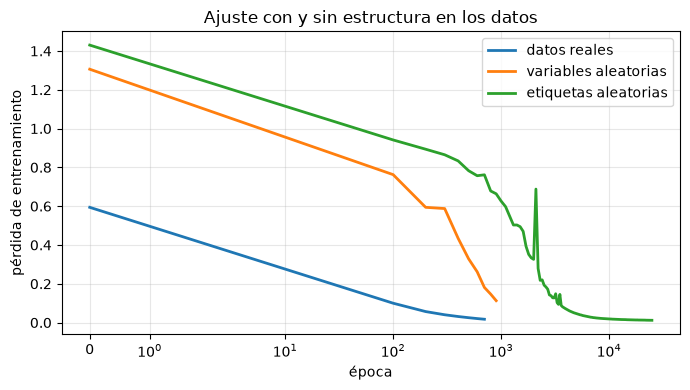

In [4]:
# Antes de nada: ¿hay filas exactamente duplicadas? Importa más de lo que parece.
_, inverso, veces = np.unique(X_bruto, axis=0, return_inverse=True, return_counts=True)
duplicadas = np.where(veces > 1)[0]
print(f"filas duplicadas exactas: {int(veces[veces > 1].sum() - len(duplicadas))}")
for d in duplicadas:
    idx = np.where(inverso == d)[0]
    print(f"  índices {idx} -> {X_bruto[idx[0]]}   etiqueta real {y_bruto[idx]}")

gen = np.random.default_rng(0)
X_ruido = gen.normal(0, 1, X_esc.shape).astype(np.float32)
y_perm = gen.permutation(y_bruto)

for d in duplicadas:                      # ¿la permutación les asigna etiquetas distintas?
    idx = np.where(inverso == d)[0]
    if len(set(y_perm[idx])) > 1:
        print(f"  CONFLICTO: {idx} son idénticas pero reciben etiquetas {y_perm[idx]}")
        print(f"  techo teórico de exactitud de entrenamiento: "
              f"{(len(y_bruto)-1)/len(y_bruto)*100:.2f}%")
print()

condiciones = {"datos reales": (X_esc, y_bruto),
               "variables aleatorias": (X_ruido, y_bruto),
               "etiquetas aleatorias": (X_esc, y_perm)}

curvas = {}
for nombre, (Xc, yc) in condiciones.items():
    Xt, yt = tensor(Xc, yc)
    red = mlp(4, [128, 128], 3, semilla=1)
    t0 = time.time()
    hist, ep = entrenar(red, Xt, yt, epocas=25_000, lr=0.1, semilla=1,
                        parar_en_cero=True, registrar_cada=100)
    curvas[nombre] = hist
    exa = evaluar(red, Xt, yt)[1]
    print(f"  {nombre:22s} épocas: {ep:6d}   exactitud de entrenamiento: {exa*100:6.2f}%   "
          f"({time.time()-t0:.1f}s, {n_par(red)} parámetros)")

plt.figure(figsize=(7, 4))
for nombre, hist in curvas.items():
    plt.plot([h[0] for h in hist], [h[1] for h in hist], label=nombre, lw=2)
plt.xlabel("época"); plt.ylabel("pérdida de entrenamiento")
plt.xscale("symlog"); plt.title("Ajuste con y sin estructura en los datos")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

**Lectura.** Con datos reales y con variables aleatorias la red llega a error de entrenamiento
**cero**. Lo único que cambia es *cuánto tarda*: reales primero, variables aleatorias después,
etiquetas aleatorias mucho más lento --- el mismo orden que reportan Zhang et al. sobre CIFAR-10.

La conclusión incómoda de la clase queda reproducida a escala de juguete: **las propiedades del
conjunto de datos no son lo que hace fácil el ajuste**. La red memoriza un mapeo sin ninguna
estructura, y por lo tanto el error de entrenamiento no informa nada sobre la generalización.

### El 99,33 % que no sube, y por qué es la mejor lección del cuaderno

Con etiquetas aleatorias la exactitud se detiene en **99,33 % = 149/150** y no se mueve, ni con
25 000 épocas ni con 200 000. Es tentador leerlo como falta de capacidad. No lo es.

Iris contiene **un par de filas exactamente idénticas** (índices 101 y 142, ambas
`[5.8, 2.7, 5.1, 1.9]`). Al permutar las etiquetas, esas dos filas reciben clases *distintas*.
Ninguna función --- ni una red, ni un árbol, ni un oráculo --- puede asignar dos salidas diferentes
a la misma entrada. El techo de 149/150 es **una contradicción en los datos**, no un límite del
modelo.

> Esto no es una curiosidad de Iris. El conjunto del estudio de casos también trae filas repetidas,
> y ahí el problema es peor: si los duplicados caen a **ambos lados** de la partición de
> validación, el modelo evalúa sobre ejemplos que ya vio y la exactitud sale inflada. Por eso la
> tarea **T1** exige contarlos *antes* de entrenar nada.

## 3. Profundidad a presupuesto de parámetros fijo

> **Clase 1.4** --- lámina *¿Es la regularización? ¿Es el ruido de SGD?* (figura 20.2 del libro).

Cuatro redes con **~4000 parámetros cada una** y 1, 2, 3 o 4 capas ocultas, ajustando etiquetas
aleatorias con gradiente de **lote completo** (proceso determinista), inicialización de He, sin
momento y sin regularización. Se elimina toda fuente de aleatoriedad salvo la inicialización.

  1 capa(s) ancho 500 ( 4003 par.)  exactitud final  94.0%


  2 capa(s) ancho  59 ( 4015 par.)  exactitud final  99.3%


  3 capa(s) ancho  42 ( 3951 par.)  exactitud final  99.3%


  4 capa(s) ancho  35 ( 4063 par.)  exactitud final  99.3%


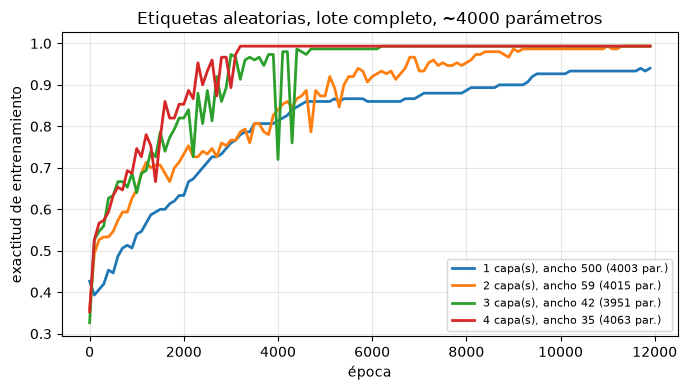

In [5]:
Xt, yt = tensor(X_esc, y_perm)
config = [(1, 500), (2, 59), (3, 42), (4, 35)]   # anchos elegidos para igualar parámetros

plt.figure(figsize=(7, 4))
for capas, ancho in config:
    red = mlp(4, [ancho] * capas, 3, semilla=2)
    hist, _ = entrenar(red, Xt, yt, epocas=12_000, lr=0.05, semilla=2, registrar_cada=100)
    plt.plot([h[0] for h in hist], [h[2] for h in hist], lw=2,
             label=f"{capas} capa(s), ancho {ancho} ({n_par(red)} par.)")
    print(f"  {capas} capa(s) ancho {ancho:3d} ({n_par(red):5d} par.)  "
          f"exactitud final {hist[-1][2]*100:5.1f}%")

plt.xlabel("época"); plt.ylabel("exactitud de entrenamiento")
plt.title("Etiquetas aleatorias, lote completo, ~4000 parámetros")
plt.legend(fontsize=8); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

**Lectura.** Dos hechos, y conviene no confundirlos.

1. **El proceso es determinista, no hay regularización, las etiquetas no tienen estructura --- y el
   error igual baja.** Ni el ruido de SGD ni la regularización explican la facilidad del ajuste.
2. **A igual número de parámetros, la red de una sola capa queda claramente atrás.** Es la
   dirección que reporta la figura 20.2. El matiz honesto: entre 2, 3 y 4 capas la diferencia se
   diluye a esta escala, así que lo que aquí se observa es *superficial contra profundo*, no una
   tendencia monótona en la profundidad. La clase advierte además que no sabemos el porqué: puede
   ser que los gradientes sean más empinados, o que la inicialización de He deje a la red ancha y
   superficial partiendo más lejos.

La hipótesis del **billete de lotería** (sección 7) es el candidato a mecanismo: a presupuesto
fijo, profundizar compra muchas más subredes que ensanchar.

## 4. Barrido de capacidad: ¿aparece el doble descenso?

> **Clase 1.4** --- lámina *Sobreparametrización y doble descenso*.
> **Estudio de casos** --- tarea **T3**.

Un MLP de una capa oculta con ancho creciente. Para que el fenómeno tenga dónde manifestarse
añadimos **20 % de ruido de etiqueta** al conjunto de entrenamiento: sin ruido, Iris es demasiado
fácil y no hay nada que sobreajustar.

⚠️ Esta celda es la más lenta del cuaderno (**~3-5 minutos**). El motivo importa: el pico del doble
descenso aparece en el **umbral de interpolación**, y para llegar ahí hay que entrenar hasta
memorizar de verdad. Con pocas épocas se ve solo la curva en U clásica.

n_entrenamiento = 105 (21 etiquetas corrompidas)


  ancho    3 (   27 par.)  train  81.4%  test  94.4%


  ancho    5 (   43 par.)  train  84.8%  test  95.6%


  ancho    8 (   67 par.)  train  88.1%  test  93.3%


  ancho   13 (  107 par.)  train  89.0%  test  87.8%


...

  ancho   55 (  443 par.)  train  98.1%  test  80.0%


  ancho   89 (  715 par.)  train 100.0%  test  85.6%


  ancho  144 ( 1155 par.)  train 100.0%  test  88.9%


  ancho  233 ( 1867 par.)  train 100.0%  test  86.7%


  ancho  377 ( 3019 par.)  train 100.0%  test  87.8%


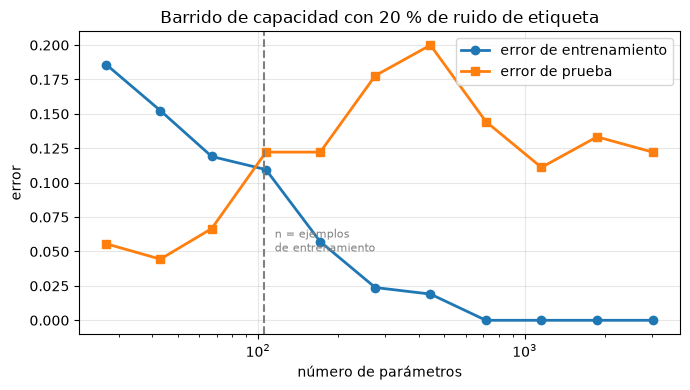

In [6]:
X_tr, X_te, y_tr, y_te = train_test_split(X_esc, y_bruto, test_size=0.3,
                                          stratify=y_bruto, random_state=0)
rg = np.random.default_rng(7)
y_tr_ruido = y_tr.copy()
i_flip = rg.choice(len(y_tr_ruido), int(0.2 * len(y_tr_ruido)), replace=False)
y_tr_ruido[i_flip] = rg.integers(0, 3, len(i_flip))

Xt, yt = tensor(X_tr, y_tr_ruido); Xv, yv = tensor(X_te, y_te)
print(f"n_entrenamiento = {len(y_tr)} ({len(i_flip)} etiquetas corrompidas)")

anchos = [3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377]
res = []
for w in anchos:
    tr, te = [], []
    for s in range(2):
        red = mlp(4, [w], 3, semilla=s)
        entrenar(red, Xt, yt, epocas=20_000, lr=0.05, semilla=s)
        tr.append(evaluar(red, Xt, yt)[1]); te.append(evaluar(red, Xv, yv)[1])
    res.append((n_par(red), np.mean(tr), np.mean(te)))
    print(f"  ancho {w:4d} ({n_par(red):5d} par.)  train {np.mean(tr)*100:5.1f}%  "
          f"test {np.mean(te)*100:5.1f}%")

par = [r[0] for r in res]
plt.figure(figsize=(7, 4))
plt.plot(par, [1-r[1] for r in res], "o-", lw=2, label="error de entrenamiento")
plt.plot(par, [1-r[2] for r in res], "s-", lw=2, label="error de prueba")
plt.axvline(len(y_tr), ls="--", c="gray")
plt.text(len(y_tr)*1.1, 0.05, "n = ejemplos\nde entrenamiento", fontsize=8, color="gray")
plt.xscale("log"); plt.xlabel("número de parámetros"); plt.ylabel("error")
plt.title("Barrido de capacidad con 20 % de ruido de etiqueta")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

**Lectura.** El error de prueba baja, **sube hasta un máximo** y vuelve a bajar. El pico aparece
justo *antes* de que el error de entrenamiento llegue a cero --- en la corrida de referencia, el
peor error de prueba está en ancho 55 (443 parámetros) y la interpolación se alcanza en ancho 89
(715 parámetros). A la izquierda estamos en el régimen clásico del compromiso sesgo/varianza; a la
derecha, en el régimen moderno donde agregar parámetros vuelve a ayudar.

Note que el umbral **no** cae sobre la línea de $n = 105$ ejemplos: hacen falta varias veces más
parámetros que datos para interpolar. Contar parámetros es una aproximación grosera a la capacidad
efectiva.

Es la curva de la lámina *Sobreparametrización y doble descenso*, reproducida con 105 ejemplos y
una capa oculta.

> **Nota experimental que importa para el caso.** Con 4000 épocas en vez de 20 000 esta misma celda
> produce una curva en U monótona **sin segundo descenso**, porque las redes anchas nunca llegan a
> interpolar. Si en el estudio de casos no observa el pico, esa es la primera hipótesis a
> descartar: puede que no esté entrenando lo suficiente, no que el fenómeno no exista.

## 5. El paisaje de la pérdida: la ruta al mínimo y las barreras entre mínimos

> **Clase 1.4** --- láminas *La ruta hacia el mínimo* y *Conexiones entre mínimos*.

Dos cortes lineales en el espacio de parámetros, siguiendo a Goodfellow et al. (2015b):

* de la **inicialización** a la solución encontrada,
* de una solución a **otra solución independiente** (otra semilla).

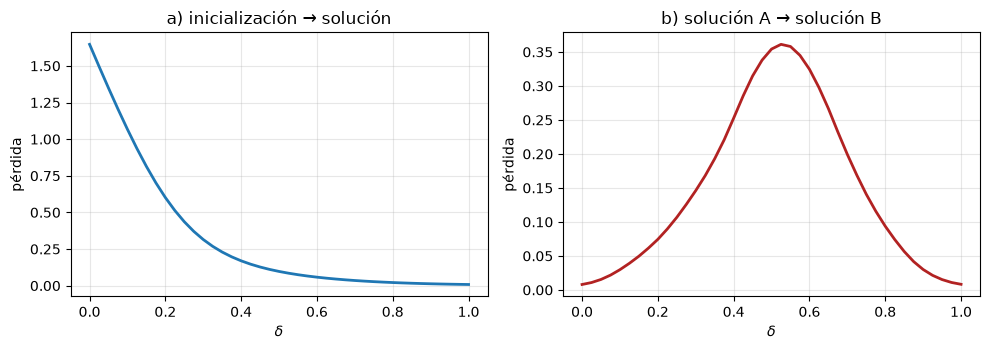

  (a) pérdida en delta=0: 1.647 → delta=1: 0.008
  (b) extremos: 0.008 / 0.008   máximo intermedio: 0.361


In [7]:
Xc, yc = tensor(X_tr, y_tr)          # sin ruido de etiqueta

red_A = mlp(4, [64, 64], 3, semilla=0)
theta_0 = copy.deepcopy(red_A.state_dict())
entrenar(red_A, Xc, yc, epocas=3000, lr=0.05, semilla=0)
theta_A = copy.deepcopy(red_A.state_dict())

red_B = mlp(4, [64, 64], 3, semilla=99)
entrenar(red_B, Xc, yc, epocas=3000, lr=0.05, semilla=99)
theta_B = copy.deepcopy(red_B.state_dict())


def interpolar(t1, t2, alfa):
    return {k: (1 - alfa) * t1[k] + alfa * t2[k] for k in t1}


sonda = mlp(4, [64, 64], 3, semilla=0)
alfas = np.linspace(0, 1, 41)
curva_init, curva_min = [], []
for a in alfas:
    sonda.load_state_dict(interpolar(theta_0, theta_A, a))
    curva_init.append(evaluar(sonda, Xc, yc)[0])
    sonda.load_state_dict(interpolar(theta_A, theta_B, a))
    curva_min.append(evaluar(sonda, Xc, yc)[0])

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].plot(alfas, curva_init, lw=2)
ax[0].set_title("a) inicialización → solución"); ax[0].set_xlabel(r"$\delta$")
ax[1].plot(alfas, curva_min, lw=2, color="firebrick")
ax[1].set_title("b) solución A → solución B"); ax[1].set_xlabel(r"$\delta$")
for a_ in ax: a_.set_ylabel("pérdida"); a_.grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f"  (a) pérdida en delta=0: {curva_init[0]:.3f} → delta=1: {curva_init[-1]:.3f}")
print(f"  (b) extremos: {curva_min[0]:.3f} / {curva_min[-1]:.3f}   "
      f"máximo intermedio: {max(curva_min):.3f}")

**Lectura.** El panel (a) desciende de forma prácticamente monótona: **en línea recta desde la
inicialización hasta la solución la pérdida solo baja**, sin valles intermedios que atravesar.

El panel (b) muestra una **barrera de energía**: dos mínimos hallados por separado tienen pérdida
baja en los extremos y alta en el medio. No están linealmente conectados. La clase agrega el
matiz de Draxler et al.: aunque el camino *recto* suba, suele existir un **camino curvo** de
pérdida baja entre ambos.

## 6. Razón lote/tasa y planitud del mínimo

> **Clase 1.4** --- láminas *El algoritmo elige a cuál mínimo llegar* y *Planitud del mínimo*.
> **Estudio de casos** --- tarea **T4**.

Medimos la planitud con el criterio de Keskar: la **pérdida máxima** en una vecindad aleatoria de
radio relativo $\varepsilon$ alrededor de los parámetros finales.

  lote    8  lr 0.01  razón    800.0   test  86.7% ±  6.5   nitidez 0.0412


  lote    8  lr 0.05  razón    160.0   test  86.7% ±  3.1   nitidez 0.0075


  lote    8  lr 0.20  razón     40.0   test  90.4% ±  4.6   nitidez 0.0048


  lote   16  lr 0.01  razón   1600.0   test  94.1% ±  1.0   nitidez 0.0344


  lote   16  lr 0.05  razón    320.0   test  84.4% ±  4.8   nitidez 0.0302


...

  lote   32  lr 0.05  razón    640.0   test  84.4% ±  4.8   nitidez 0.0577


  lote   32  lr 0.20  razón    160.0   test  84.4% ±  0.0   nitidez 0.0098


  lote  105  lr 0.01  razón  10500.0   test  96.3% ±  1.0   nitidez 0.0124


  lote  105  lr 0.05  razón   2100.0   test  94.8% ±  1.0   nitidez 0.0248


  lote  105  lr 0.20  razón    525.0   test  84.4% ±  6.3   nitidez 0.0310


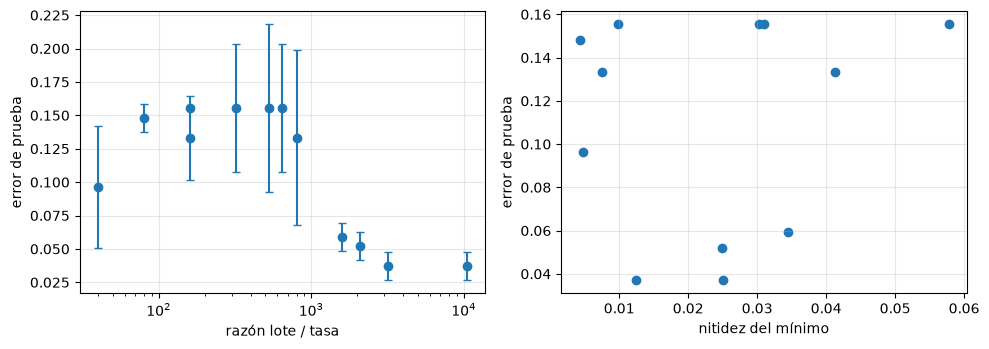

In [8]:
def nitidez(red, X, y, eps_rel=0.05, direcciones=15, semilla=0):
    """Criterio de Keskar: mayor aumento de pérdida en una bola de radio eps_rel*||theta||."""
    g = torch.Generator(device=DEV).manual_seed(semilla)
    base = evaluar(red, X, y)[0]
    theta = copy.deepcopy(red.state_dict())
    norma = torch.sqrt(sum((p ** 2).sum() for p in red.parameters())).item()
    peor = 0.0
    for _ in range(direcciones):
        d = {k: torch.randn(v.shape, generator=g, device=DEV) for k, v in theta.items()}
        nd = torch.sqrt(sum((v ** 2).sum() for v in d.values())).item()
        red.load_state_dict({k: theta[k] + eps_rel * norma * d[k] / nd for k in theta})
        peor = max(peor, evaluar(red, X, y)[0] - base)
    red.load_state_dict(theta)
    return peor


Xn, yn = tensor(X_tr, y_tr_ruido)     # con ruido: si no, la exactitud satura y no se ve nada
filas = []
for lote in [8, 16, 32, len(y_tr)]:
    for lr in [0.01, 0.05, 0.2]:
        acc, nit = [], []
        for s in range(3):
            red = mlp(4, [64, 64], 3, semilla=s)
            entrenar(red, Xn, yn, epocas=800, lr=lr, lote=lote, semilla=s)
            acc.append(evaluar(red, Xv, yv)[1]); nit.append(nitidez(red, Xn, yn, semilla=s))
        filas.append((lote / lr, np.mean(acc), np.std(acc), np.mean(nit)))
        print(f"  lote {lote:4d}  lr {lr:.2f}  razón {lote/lr:8.1f}   "
              f"test {np.mean(acc)*100:5.1f}% ± {np.std(acc)*100:4.1f}   "
              f"nitidez {np.mean(nit):.4f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].errorbar([f[0] for f in filas], [1-f[1] for f in filas],
               yerr=[f[2] for f in filas], fmt="o", capsize=3)
ax[0].set_xscale("log"); ax[0].set_xlabel("razón lote / tasa"); ax[0].set_ylabel("error de prueba")
ax[1].scatter([f[3] for f in filas], [1-f[1] for f in filas])
ax[1].set_xlabel("nitidez del mínimo"); ax[1].set_ylabel("error de prueba")
for a_ in ax: a_.grid(alpha=.3)
plt.tight_layout(); plt.show()

**Lectura --- y aquí el resultado es negativo.** A esta escala **no se separa ninguna relación
limpia** entre la razón lote/tasa y la generalización, ni entre la nitidez del mínimo y el error de
prueba. Con 105 ejemplos de entrenamiento y tres semillas, la dispersión entre repeticiones es del
mismo orden que el efecto que se busca medir.

Eso no refuta la lámina de la clase: la evidencia de He et al. (2019) y Keskar et al. (2017) viene
de CIFAR-10 con decenas de miles de ejemplos. Lo que muestra es **cuánta potencia estadística hace
falta** para afirmar algo aquí. En el estudio de casos, con diez veces más datos, la tarea T4 pide
exactamente esta medición --- y pide reportar honestamente si el efecto se separa del ruido.

## 7. La hipótesis del billete de lotería

> **Clase 1.4** --- láminas *Activación, inicialización y profundidad* y *Poda*.
> **Estudio de casos** --- tarea **T5**.

El procedimiento de Frankle & Carbin: entrenar, podar por magnitud, y reentrenar la subred
**desde los pesos iniciales originales**. El control es reentrenarla desde una inicialización
nueva. Si la primera gana, la red contenía un *billete ganador*.

In [9]:
def mascaras_por_magnitud(red, fraccion):
    """Máscaras globales que conservan la fracción indicada de pesos de mayor magnitud."""
    pesos = [p for p in red.parameters() if p.dim() > 1]
    todos = torch.cat([p.detach().abs().flatten() for p in pesos])
    umbral = torch.quantile(todos, 1 - fraccion)
    return [(p.detach().abs() >= umbral).float() for p in pesos]


for fraccion in [0.20, 0.10, 0.05, 0.02]:
    resultado = {"init original": [], "init nueva": []}
    for s in range(5):
        base = mlp(4, [64, 64], 3, semilla=s)
        theta_ini = copy.deepcopy(base.state_dict())
        entrenar(base, Xn, yn, epocas=2500, lr=0.05, semilla=s)
        masc = mascaras_por_magnitud(base, fraccion)

        for etiqueta, semilla_nueva in [("init original", None), ("init nueva", 1000 + s)]:
            sub = mlp(4, [64, 64], 3, semilla=s if semilla_nueva is None else semilla_nueva)
            if semilla_nueva is None:
                sub.load_state_dict(theta_ini)
            with torch.no_grad():
                for p, mk in zip([q for q in sub.parameters() if q.dim() > 1], masc):
                    p.mul_(mk)
            entrenar(sub, Xn, yn, epocas=2500, lr=0.05, semilla=s, mascaras=masc)
            resultado[etiqueta].append(evaluar(sub, Xv, yv)[1])

    o, n_ = resultado["init original"], resultado["init nueva"]
    print(f"  {int(fraccion*100):2d}% de los pesos:  init original {np.mean(o)*100:5.1f}% ± {np.std(o)*100:4.1f}"
          f"   |   init nueva {np.mean(n_)*100:5.1f}% ± {np.std(n_)*100:4.1f}")

  20% de los pesos:  init original  92.9% ±  0.9   |   init nueva  96.4% ±  1.1


  10% de los pesos:  init original  94.2% ±  1.1   |   init nueva  96.4% ±  1.1


   5% de los pesos:  init original  94.7% ±  1.8   |   init nueva  96.4% ±  2.3


   2% de los pesos:  init original  33.3% ±  0.0   |   init nueva  33.3% ±  0.0


**Lectura --- segundo resultado negativo, y es el interesante.** La subred reentrenada desde la
inicialización original **no supera** a la reentrenada desde una inicialización nueva; con 5
semillas la diferencia no es distinguible del ruido, e incluso puede invertirse. Al 2 % de los
pesos ambas colapsan al nivel del azar: ya no queda red.

Es decir: **a esta escala no hay billetes ganadores**. Y eso es coherente con el mecanismo, no una
refutación: si una red sobreparametrizada funciona porque compra muchas subredes, un MLP de 4675
parámetros sobre 105 ejemplos simplemente **no compró suficientes**. El resultado de
Frankle & Carbin se obtuvo sobre VGG-19 con 138 millones de parámetros.

La tarea T5 del estudio de casos anticipa este desenlace y pide justamente esa discusión.

## 8. La norma de los pesos y la zona Goldilocks

> **Clase 1.4** --- lámina *La norma de los pesos y el grokking*.

Escalamos la inicialización de He por un factor $\alpha$ y observamos qué pasa con la
generalización. La norma $\ell_2$ de los pesos está indirectamente relacionada con la constante de
Lipschitz del modelo: demasiado grande y el modelo varía en exceso entre los datos.

  alfa  0.05  ||theta_0|| =   0.84   train  98.1%   test 100.0% ±  0.0


  alfa  0.10  ||theta_0|| =   1.68   train  98.1%   test 100.0% ±  0.0


  alfa  0.25  ||theta_0|| =   4.19   train  98.1%   test 100.0% ±  0.0


  alfa  0.50  ||theta_0|| =   8.39   train  98.7%   test  99.3% ±  1.0


  alfa  1.00  ||theta_0|| =  16.78   train 100.0%   test  96.3% ±  1.0


  alfa  2.00  ||theta_0|| =  33.56   train 100.0%   test  94.8% ±  1.0


  alfa  4.00  ||theta_0|| =  67.11   train 100.0%   test  90.4% ±  2.8


  alfa  8.00  ||theta_0|| = 134.23   train 100.0%   test  85.9% ±  1.0


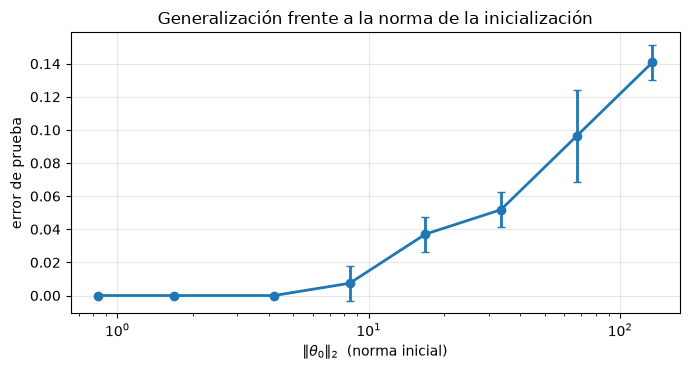

In [10]:
escalas, medias, desv, normas = [0.05, 0.1, 0.25, 0.5, 1, 2, 4, 8], [], [], []
for alfa in escalas:
    tr, te = [], []
    for s in [5, 6, 7]:
        red = mlp(4, [64, 64], 3, semilla=s)
        with torch.no_grad():
            for p in red.parameters():
                if p.dim() > 1:
                    p.mul_(alfa)
        if s == 5:
            normas.append(torch.sqrt(sum((p**2).sum() for p in red.parameters())).item())
        entrenar(red, Xc, yc, epocas=3000, lr=0.05, semilla=s)
        tr.append(evaluar(red, Xc, yc)[1]); te.append(evaluar(red, Xv, yv)[1])
    medias.append(np.mean(te)); desv.append(np.std(te))
    print(f"  alfa {alfa:5.2f}  ||theta_0|| = {normas[-1]:6.2f}   "
          f"train {np.mean(tr)*100:5.1f}%   test {np.mean(te)*100:5.1f}% ± {np.std(te)*100:4.1f}")

plt.figure(figsize=(7, 3.8))
plt.errorbar(normas, [1-m for m in medias], yerr=desv, fmt="o-", capsize=3, lw=2)
plt.xscale("log"); plt.xlabel(r"$\|\theta_0\|_2$  (norma inicial)")
plt.ylabel("error de prueba"); plt.title("Generalización frente a la norma de la inicialización")
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

**Lectura.** La degradación con $\alpha$ creciente es limpia y monótona: partir con pesos grandes
produce una función que ajusta igual de bien el entrenamiento pero **varía demasiado entre los
datos**. Es el lado derecho de la zona Goldilocks.

El lado izquierdo no aparece: incluso con $\alpha = 0{,}05$ la red generaliza perfectamente, porque
la frontera que Iris necesita es casi lineal y no exige una constante de Lipschitz grande. Para
exponer ese lado haría falta una función objetivo que varíe más rápido.

Esta es la mecánica que la clase usa para explicar el **grokking**: si la norma inicial es
demasiado grande, el modelo ajusta pronto pero generaliza tarde, cuando la regularización
--- explícita o implícita --- consigue bajar la norma hasta la zona buena.

## 9. Salir de la variedad de datos: ejemplos adversarios

> **Clase 1.4** --- lámina *Salir de la variedad de datos: ejemplos adversarios*.
> **Estudio de casos** --- tarea **T7**.

FGSM sobre datos tabulares. La perturbación se mide **en desviaciones estándar de cada variable**,
lo que la hace interpretable: en el caso clínico, $\varepsilon = 0{,}1$ es del orden del error de
un tensiómetro.

  eps = 0.00 desv. est.   exactitud  95.6%
  eps = 0.02 desv. est.   exactitud  95.6%
  eps = 0.05 desv. est.   exactitud  93.3%
  eps = 0.10 desv. est.   exactitud  91.1%
  eps = 0.15 desv. est.   exactitud  84.4%
  eps = 0.20 desv. est.   exactitud  80.0%
  eps = 0.30 desv. est.   exactitud  62.2%
  eps = 0.50 desv. est.   exactitud  51.1%


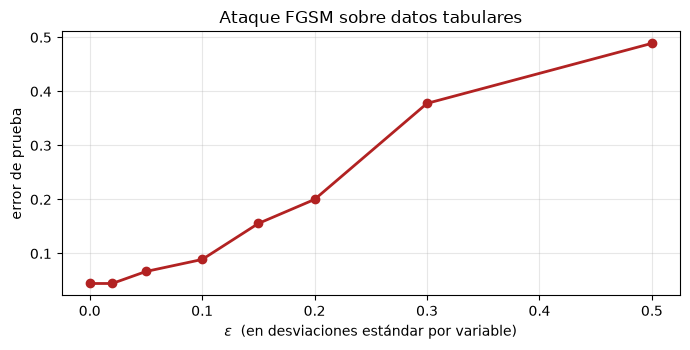

In [11]:
red = mlp(4, [64, 64], 3, semilla=0)
entrenar(red, Xc, yc, epocas=3000, lr=0.05, semilla=0)

X_adv = Xv.clone().requires_grad_(True)
CE(red(X_adv), yv).backward()
direccion = X_adv.grad.sign()

eps_grid = [0.0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5]
accs = []
for eps in eps_grid:
    with torch.no_grad():
        accs.append((red(Xv + eps * direccion).argmax(1) == yv).float().mean().item())
    print(f"  eps = {eps:.2f} desv. est.   exactitud {accs[-1]*100:5.1f}%")

plt.figure(figsize=(7, 3.6))
plt.plot(eps_grid, [1-a for a in accs], "o-", lw=2, color="firebrick")
plt.xlabel(r"$\varepsilon$  (en desviaciones estándar por variable)")
plt.ylabel("error de prueba"); plt.title("Ataque FGSM sobre datos tabulares")
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

**Lectura.** Una perturbación de una décima de desviación estándar --- indistinguible del error de
medición --- ya degrada el modelo de forma apreciable. En imágenes la analogía es visual; en datos
clínicos es **más concreta y más incómoda**, porque esa magnitud de error existe de verdad en el
instrumento.

La explicación actual (Ilyas et al., 2019) no es falta de robustez fuera de la distribución: el
ataque **explota señales reales** de la distribución de entrenamiento, de norma pequeña.

---

## 10. Qué se reprodujo y qué no

| Sección | Fenómeno de la clase 1.4 | ¿Se reprodujo en Iris? |
|---|---|---|
| 1 | La red no supera a los árboles en tabular pequeño | **Sí** (empate; en el caso, la red pierde) |
| 2 | Zhang: se ajustan datos y etiquetas sin estructura | **Sí**, y el techo de 99,33 % resultó ser un duplicado |
| 3 | Determinismo y sin regularización: igual ajusta | **Sí** |
| 3 | A parámetros fijos, más profundo ajusta más rápido | **Parcial** --- solo 1 capa contra el resto |
| 4 | Doble descenso alrededor del umbral de interpolación | **Sí**, pero solo con entrenamiento largo |
| 5 | Descenso monótono init → solución | **Sí** |
| 5 | Barrera entre dos mínimos independientes | **Sí** |
| 6 | Razón lote/tasa y planitud predicen generalización | **No** --- el ruido domina a esta escala |
| 7 | Billete de lotería | **No** --- la red es demasiado pequeña |
| 8 | Norma inicial grande perjudica la generalización | **Sí** (solo el lado derecho de la zona) |
| 9 | Ejemplos adversarios | **Sí** |

**Nueve de once, con matices.** Los dos negativos son informativos: ambos corresponden a fenómenos que la
literatura documenta a escalas mucho mayores, y ambos son objeto de tareas específicas del estudio
de casos. Un resultado negativo bien establecido --- con semillas suficientes y dispersión
reportada --- vale tanto como uno positivo.

---

## 11. Cómo llevar esto al estudio de casos

El estudio de casos usa **Maternal Health Risk** (UCI id 863): 1014 ejemplos, 6 variables, 3 clases
de riesgo. Es el mismo tipo de problema, diez veces más grande.

Para migrar basta con **reemplazar la celda de carga de datos**; todas las funciones de la sección 0
funcionan sin cambios (solo hay que ajustar `entrada=6` en las llamadas a `mlp`):

```python
!pip install -q ucimlrepo
from ucimlrepo import fetch_ucirepo

mhr = fetch_ucirepo(id=863)
X_bruto = mhr.data.features.to_numpy().astype(np.float32)
y_bruto = mhr.data.targets["RiskLevel"].map(
    {"low risk": 0, "mid risk": 1, "high risk": 2}).to_numpy().astype(np.int64)
X_esc = StandardScaler().fit_transform(X_bruto).astype(np.float32)
```

### Correspondencia con las tareas

| Tarea del caso | Sección de este cuaderno | Qué hay que agregar |
|---|---|---|
| **T1** Línea base y auditoría | 1 y 2 | el detector de duplicados ya está escrito; falta F1 por clase y matriz de confusión |
| **T2** Memorización | 2 | reportar parámetros mínimos para memorizar frente a *n* |
| **T3** Doble descenso | 4 | 5 semillas, y verificar que se alcanza la interpolación |
| **T4** Lote/tasa y planitud | 6 | más semillas: aquí el efecto no se separó del ruido |
| **T5** Billete de lotería | 7 | discutir por qué el efecto depende de la escala |
| **T6** Sesgo inductivo | 1 | contraprueba: dos intervenciones para cerrar la brecha |
| **T7** Lectura clínica | 9 | matriz de costos asimétrica y sensibilidad de *high risk* |

### Tres advertencias antes de empezar

1. **El conjunto real trae filas duplicadas.** Si caen a ambos lados de la partición, la exactitud
   que obtenga estará inflada. Cuéntelas antes de entrenar nada (T1).
2. **Las clases están desbalanceadas** (406/336/272). La exactitud sola es un mal resumen.
3. **El costo del error es asimétrico.** Un falso negativo de *high risk* no equivale a un falso
   positivo de *low risk*, y eso debe entrar en la métrica, no solo en la discusión.

---

*Material del curso MDS221, Magíster en Data Science, Universidad Católica del Maule.
Basado en Prince,* Understanding Deep Learning*, cap. 20.*